In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df_auditor_benchmark_sign = pd.read_excel('Auditor-benchmark.xlsx', sheet_name='BlocklistsizeExp')
df_auditor_benchmark_sign_2 = pd.read_excel('Auditor-benchmark.xlsx', sheet_name='BlocklistsizeExp2')
df_auditor_benchmark_sign_3 = pd.read_excel('Auditor-benchmark.xlsx', sheet_name='BlocklistsizeExp3')


df_auditor_benchmark_update = pd.read_excel('Auditor-benchmark.xlsx', sheet_name='BlocklistUpdate')


df_exact_pre = pd.read_excel('content_mod_perf.xlsx', sheet_name='exact_match_pre')

df_exact_comm = pd.read_excel('content_mod_perf.xlsx', sheet_name='exact_match_comm')

print(df_exact_pre.columns)

df_exact_nopre = pd.read_excel('content_mod_perf.xlsx', sheet_name='exact_match_nopre')
df_exact_comm = pd.read_excel('content_mod_perf.xlsx', sheet_name='exact_match_comm')
df_exact_storage = pd.read_excel('content_mod_perf.xlsx', sheet_name='exact_match_storage')
df_approx_10 = pd.read_excel('content_mod_perf.xlsx', sheet_name='approx_match_10')
df_approx_20 = pd.read_excel('content_mod_perf.xlsx', sheet_name='approx_match_20')
df_approx_30 = pd.read_excel('content_mod_perf.xlsx', sheet_name='approx_match_30')
df_approx_40 = pd.read_excel('content_mod_perf.xlsx', sheet_name='approx_match_40')
df_approx_50 = pd.read_excel('content_mod_perf.xlsx', sheet_name='approx_match_50')

df_exact_pre.columns
df_approx_no_pre_10 = pd.read_excel('content_mod_perf.xlsx', sheet_name='approx_match_nopre_10')
df_approx_no_pre_20 = pd.read_excel('content_mod_perf.xlsx', sheet_name='approx_match_nopre_20')
df_approx_preprocess = pd.read_excel('content_mod_perf.xlsx', sheet_name='approx_preprocess')

df_exact_comm.columns

Index(['DB size log', 'DB size', 'auditor preprocess time',
       'client preprocess time', 'server preprocess time', 'client query time',
       'server query time', 'client sig compute time',
       'server sig verification time', 'server total time',
       'server total time 10p', 'server total time 20p',
       'server total time 25p', 'server total time 40p',
       'server total time 75p', 'server total time 5p',
       'server total time 10p.1', 'server total time 50p', 'storage cost',
       'PHM query time', 'PHM sig time', 'PHM log scale', 'PHM throughput',
       'PHM throughput logscale', 'Client throughput', 'PHM comm', 'Sig size',
       'comm preprocess', 'comm query', 'amortized comm', 'total comm',
       'client comput time', 'client compute time log scale'],
      dtype='object')


Index(['DB size log', 'DB size', 'BF size', 'Sig Size', 'comm nofp',
       'comm 75p', 'comm 50p', 'comm 25p', 'comm 10p', 'comm 5p', 'Comm log',
       'PEMC comm'],
      dtype='object')

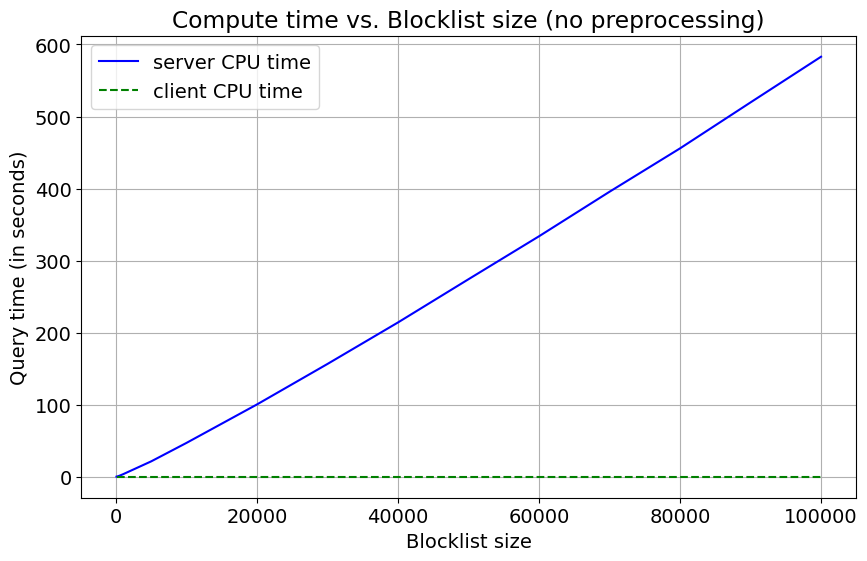

In [27]:
plt.rcParams['axes.prop_cycle'] = plt.cycler(
    color=['b', 'g', 'r', 'c', 'm'],
    linestyle=['-', '--', ':', '-.', '-']
)



plt.figure(figsize=(10, 6))
plt.plot(df_exact_nopre['DB size'], df_exact_nopre['Server compute time'], label='server CPU time')
plt.plot(df_exact_nopre['DB size'], df_exact_nopre['Client compute time'], label='client CPU time')
plt.rc('font', size=14)

# Adding labels and title
plt.xlabel('Blocklist size')
plt.ylabel('Query time (in seconds)')
plt.title('Compute time vs. Blocklist size (no preprocessing)')
plt.legend()
plt.grid(True)

plt.savefig("figs/server_sigtime_blocklistsize_nopre.pdf", format="pdf") 

plt.show()



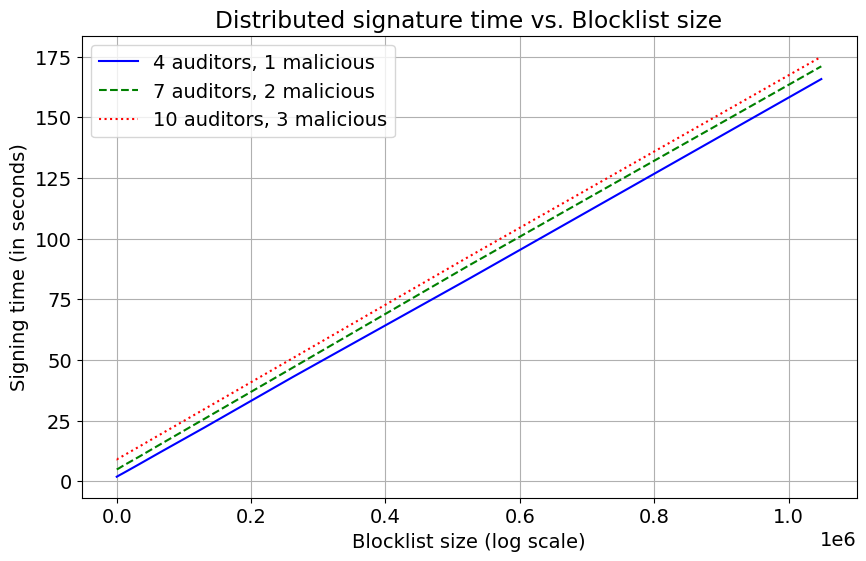

In [23]:
plt.rcParams['axes.prop_cycle'] = plt.cycler(
    color=['b', 'g', 'r', 'c', 'm'],
    linestyle=['-', '--', ':', '-.', '-']
)




plt.figure(figsize=(10, 6))
plt.plot(df_auditor_benchmark_sign['Blocklist size'], df_auditor_benchmark_sign['Time'], label='4 auditors, 1 malicious')
plt.plot(df_auditor_benchmark_sign_2['Blocklist size'], df_auditor_benchmark_sign_2['Time'], label='7 auditors, 2 malicious')
plt.plot(df_auditor_benchmark_sign_3['Blocklist size'], df_auditor_benchmark_sign_3['Time'], label='10 auditors, 3 malicious')
plt.rc('font', size=14)

# Adding labels and title
plt.xlabel('Blocklist size (log scale)')
plt.ylabel('Signing time (in seconds)')
plt.title('Distributed signature time vs. Blocklist size')
plt.legend()
plt.grid(True)

plt.savefig("figs/server_sigtime.pdf", format="pdf") 

plt.show()

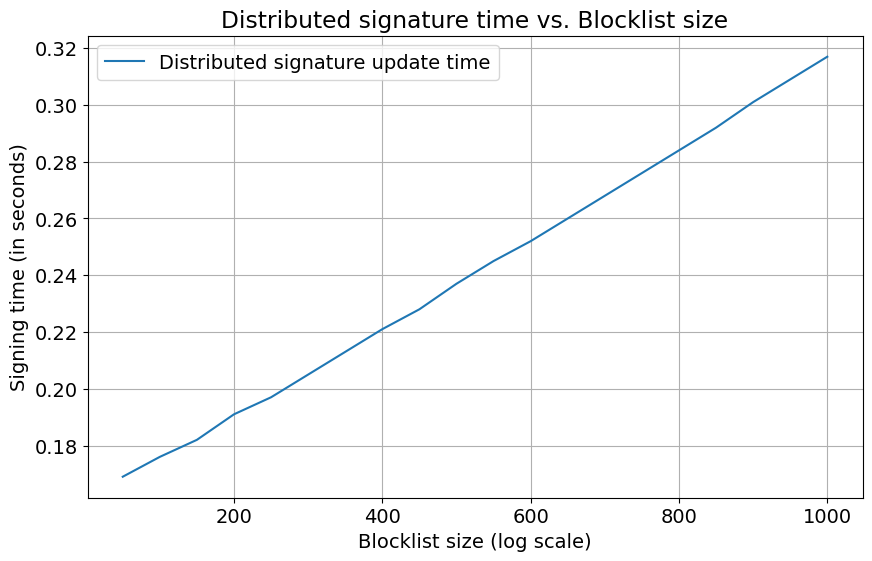

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_auditor_benchmark_update['Update size'], df_auditor_benchmark_update['Time'], label='Distributed signature update time')
plt.rc('font', size=14)

# Adding labels and title
plt.xlabel('Blocklist size (log scale)')
plt.ylabel('Signing time (in seconds)')
plt.title('Distributed signature time vs. Blocklist size')
plt.legend()
plt.grid(True)

plt.savefig("figs/server_sigtime_update.pdf", format="pdf") 

plt.show()

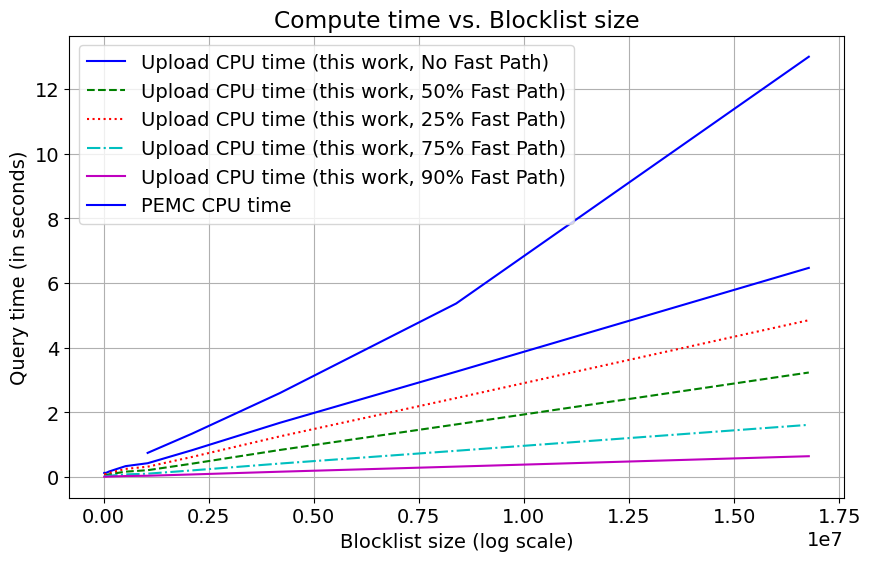

In [24]:
plt.rcParams['axes.prop_cycle'] = plt.cycler(
    color=['b', 'g', 'r', 'c', 'm'],
    linestyle=['-', '--', ':', '-.', '-']
)



plt.figure(figsize=(10, 6))
plt.plot(df_exact_pre['DB size'], df_exact_pre['server total time'], label='Upload CPU time (this work, No Fast Path)')
plt.plot(df_exact_pre['DB size'], df_exact_pre['server total time 50p'], label='Upload CPU time (this work, 50% Fast Path)')
plt.plot(df_exact_pre['DB size'], df_exact_pre['server total time 75p'], label='Upload CPU time (this work, 25% Fast Path)')
plt.plot(df_exact_pre['DB size'], df_exact_pre['server total time 25p'], label='Upload CPU time (this work, 75% Fast Path)')
plt.plot(df_exact_pre['DB size'], df_exact_pre['server total time 10p'], label='Upload CPU time (this work, 90% Fast Path)')

#plt.plot(df_exact_pre['DB size'], df_exact_pre['server total time 5p'], label='Upload CPU time (this work, 95% Fast Path)')

plt.plot(df_exact_pre['DB size'], df_exact_pre['PHM query time'], label='PEMC CPU time')

#plt.plot(df_exact_pre['DB size'], df_exact_pre['client compute time log scale'], label='client CPU time (this work)')


plt.rc('font', size=14)

# Adding labels and title
plt.xlabel('Blocklist size (log scale)')
plt.ylabel('Query time (in seconds)')
plt.title('Compute time vs. Blocklist size')
plt.legend()
plt.grid(True)

plt.savefig("figs/server_sigtime_blocklistsize_pre.pdf", format="pdf") # Saves as PNG by default

plt.show()

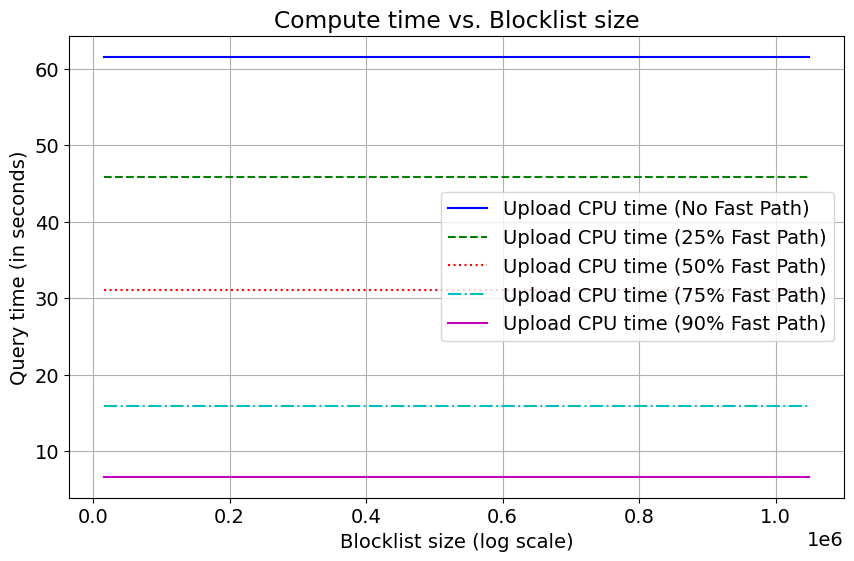

In [31]:
plt.rcParams['axes.prop_cycle'] = plt.cycler(
    color=['b', 'g', 'r', 'c', 'm'],
    linestyle=['-', '--', ':', '-.', '-']
)



plt.figure(figsize=(10, 6))
plt.plot(df_approx_20['DB size'], df_approx_20['time nofp'], label='Upload CPU time (No Fast Path)')
plt.plot(df_approx_20['DB size'], df_approx_20['time 75p'], label='Upload CPU time (25% Fast Path)')
plt.plot(df_approx_20['DB size'], df_approx_20['time 50p'], label='Upload CPU time (50% Fast Path)')
plt.plot(df_approx_20['DB size'], df_approx_20['time 25p'], label='Upload CPU time (75% Fast Path)')
plt.plot(df_approx_20['DB size'], df_approx_20['time 10p'], label='Upload CPU time (90% Fast Path)')
#plt.plot(df_approx_20['DB size'], df_approx_20['time 5p'], label='Upload CPU time (95% Fast Path)')

#plt.plot(df_exact_pre['DB size'], df_exact_pre['server total time 50p'], label='Upload CPU time (this work, 50% Fast Path)')
#plt.plot(df_exact_pre['DB size'], df_exact_pre['server total time 75p'], label='Upload CPU time (this work, 25% Fast Path)')
#plt.plot(df_exact_pre['DB size'], df_exact_pre['server total time 25p'], label='Upload CPU time (this work, 75% Fast Path)')
#plt.plot(df_exact_pre['DB size'], df_exact_pre['server total time 5p'], label='Upload CPU time (this work, 95% Fast Path)')

#plt.plot(df_exact_pre['DB size'], df_exact_pre['PHM query time'], label='PEMC CPU time')

#plt.plot(df_exact_pre['DB size'], df_exact_pre['client compute time log scale'], label='client CPU time (this work)')


plt.rc('font', size=14)

# Adding labels and title
plt.xlabel('Blocklist size (log scale)')
plt.ylabel('Query time (in seconds)')
plt.title('Compute time vs. Blocklist size')
plt.legend()
plt.grid(True)

plt.savefig("figs/server_sigtime_blocklistsize_pre_approx.pdf", format="pdf") # Saves 

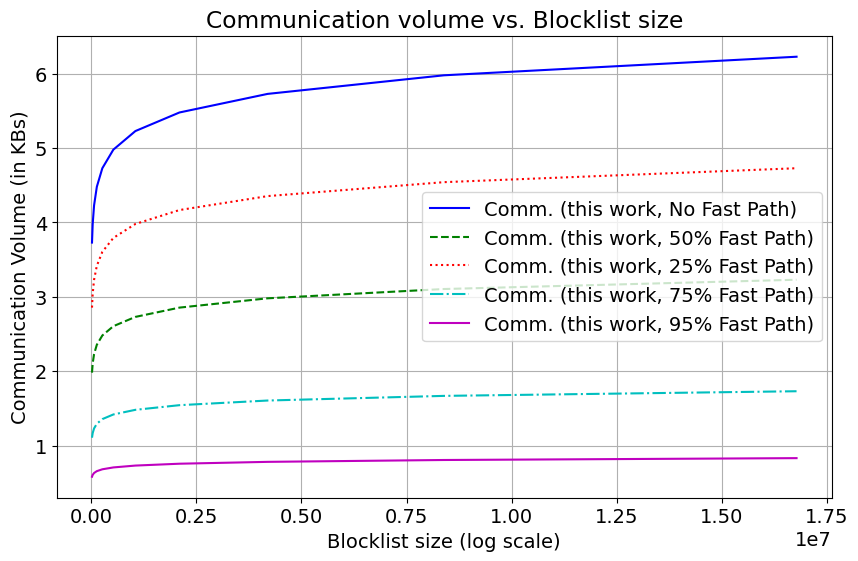

In [ ]:
plt.rcParams['axes.prop_cycle'] = plt.cycler(
    color=['b', 'g', 'r', 'c', 'm'],
    linestyle=['-', '--', ':', '-.', '-']
)



plt.figure(figsize=(10, 6))
plt.plot(df_exact_comm['DB size'], df_exact_comm['comm nofp'], label='Comm. (this work, No Fast Path)')
plt.plot(df_exact_comm['DB size'], df_exact_comm['comm 50p'], label='Comm. (this work, 50% Fast Path)')
plt.plot(df_exact_comm['DB size'], df_exact_comm['comm 75p'], label='Comm. (this work, 25% Fast Path)')
plt.plot(df_exact_comm['DB size'], df_exact_comm['comm 25p'], label='Comm. (this work, 75% Fast Path)')
plt.plot(df_exact_comm['DB size'], df_exact_comm['comm 10p'], label='Comm. (this work, 90% Fast Path)')
#plt.plot(df_exact_comm['DB size'], df_exact_comm['comm 5p'], label='Comm. (this work, 95% Fast Path)')
#plt.plot(df_exact_comm['DB size'], df_exact_comm['PEMC comm'], label='PEMC Comm.')

plt.rc('font', size=14)

# Adding labels and title
plt.xlabel('Blocklist size (log scale)')
plt.ylabel('Communication Volume (in KBs)')
plt.title('Communication volume vs. Blocklist size')
plt.legend()
plt.grid(True)

plt.savefig("figs/server_comm_blocklistsize_pre.pdf", format="pdf") # Saves as PNG by default

plt.show()

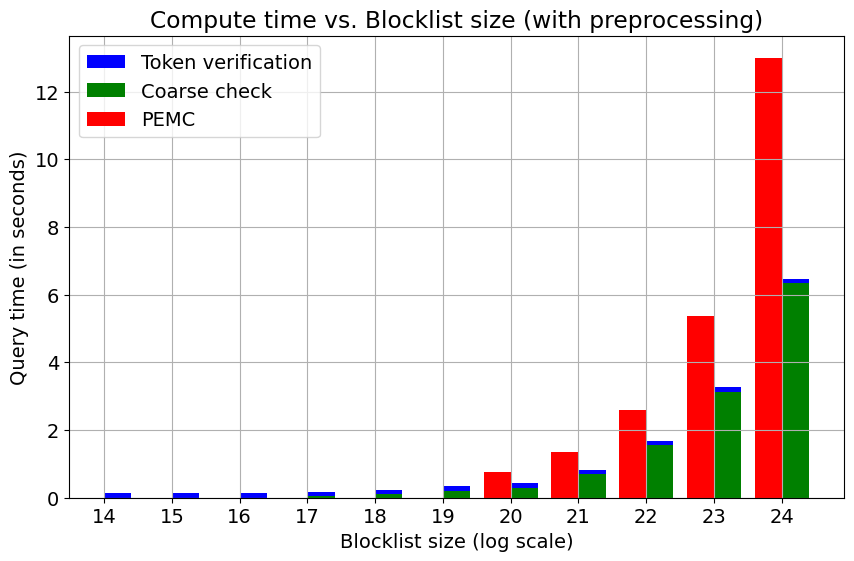

In [34]:

df = df_exact_pre[['DB size log', 'server query time', 'server total time', 'PHM query time']]
fig = plt.figure(figsize=(10, 6))
plt.xticks(np.arange(min(df['DB size log']), max(df['DB size log'])+1, 1.0))




ab_bar_list = [plt.bar(df['DB size log'], df['server total time'], align='edge',    width= 0.4,label='Token verification'),
               plt.bar(df['DB size log'], df['server query time'], align='edge', width= 0.4, label='Coarse check')]

cd_bar_list = [plt.bar(df['DB size log'], df['PHM query time'], align='edge',width= -0.4, label = 'PEMC')]



# Adding labels and title
plt.xlabel('Blocklist size (log scale)')
plt.ylabel('Query time (in seconds)')
plt.title('Compute time vs. Blocklist size (with preprocessing)')
plt.legend(loc='upper left')
plt.grid(True)

plt.savefig("figs/server_sigtime_blocklistsize_pre.pdf", format="pdf") # Saves as PNG by default

plt.show()


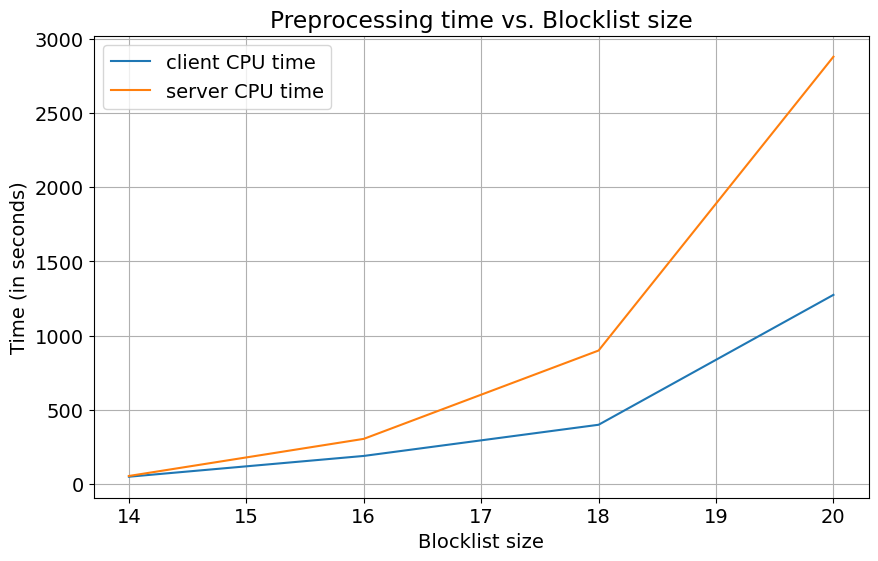

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(df_approx_preprocess['DB size'], df_approx_preprocess['Client time'], label="client CPU time")
plt.plot(df_approx_preprocess['DB size'], df_approx_preprocess['Server time'], label="server CPU time")
plt.rc('font', size=14)

# Adding labels and title
plt.xlabel('Blocklist size')
plt.ylabel('Time (in seconds)')
plt.title('Preprocessing time vs. Blocklist size')
plt.legend()
plt.grid(True)

plt.savefig("figs/client_preprocess_time_blocklistsize_approx.pdf", format="pdf") # Saves as PNG by default

plt.show()

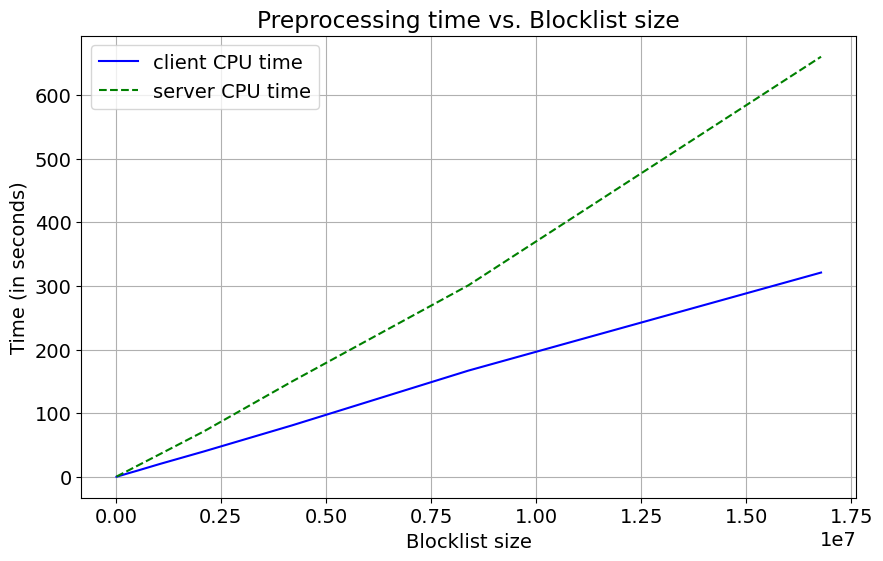

In [28]:
plt.rcParams['axes.prop_cycle'] = plt.cycler(
    color=['b', 'g', 'r', 'c', 'm'],
    linestyle=['-', '--', ':', '-.', '-']
)



plt.figure(figsize=(10, 6))
plt.plot(df_exact_pre['DB size'], df_exact_pre['client preprocess time'], label="client CPU time")
plt.plot(df_exact_pre['DB size'], df_exact_pre['server preprocess time'], label="server CPU time")
plt.rc('font', size=14)

# Adding labels and title
plt.xlabel('Blocklist size')
plt.ylabel('Time (in seconds)')
plt.title('Preprocessing time vs. Blocklist size')
plt.legend()
plt.grid(True)

plt.savefig("figs/client_preprocess_time_blocklistsize.pdf", format="pdf") # Saves as PNG by default

plt.show()

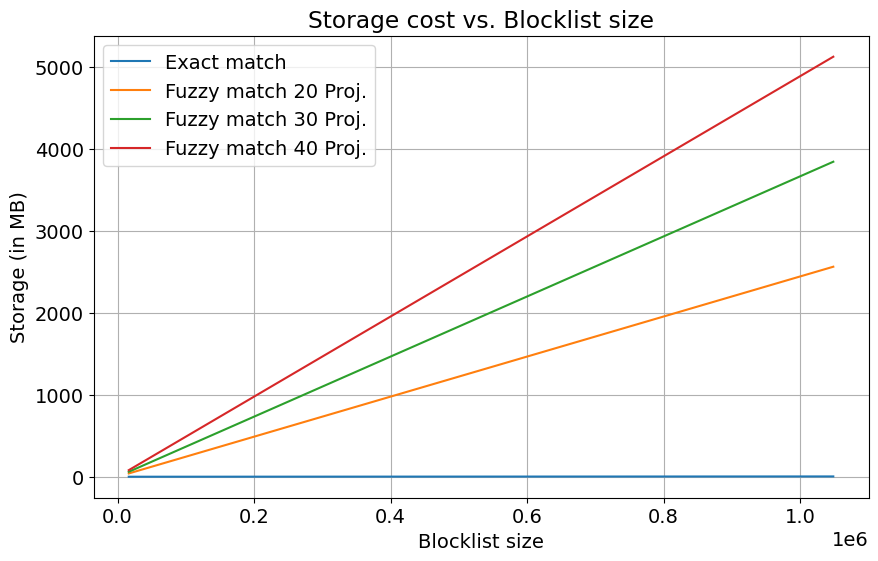

In [7]:
plt.figure(figsize=(10, 6))
#plt.plot(df_exact_pre['DB size'], df_exact_pre['storage cost'], label="Exact matching")
plt.plot(df_exact_storage['DB size'], df_exact_storage['storage'], label="Exact match")
plt.plot(df_approx_20['DB size'], df_approx_20['storage'], label="Fuzzy match 20 Proj.")
plt.plot(df_approx_30['DB size'], df_approx_30['storage'], label="Fuzzy match 30 Proj.")
plt.plot(df_approx_40['DB size'], df_approx_40['storage'], label="Fuzzy match 40 Proj.")
plt.rc('font', size=14)

# Adding labels and title
plt.xlabel('Blocklist size')
plt.ylabel('Storage (in MB)')
plt.title('Storage cost vs. Blocklist size')
plt.legend()
plt.grid(True)

plt.savefig("figs/client_storage_blocklistsize.pdf", format="pdf") # Saves as PNG by default

plt.show()

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(df_exact_pre['DB size log scale'], df_exact_pre['storage cost'])

# Adding labels and title
plt.xlabel('blocklist size (log scale)')
plt.ylabel('Storage cost (in MB)')
plt.title('Server storage cost vs. Blocklist size')
plt.legend()
plt.grid(True)

plt.savefig("figs/server_storage_blocklistsize_pre.pdf", format='pdf') # Saves as PNG by default

plt.show()

KeyError: 'DB size log scale'

<Figure size 1000x600 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_exact_pre['DB size log scale'], df_exact_pre['comm preprocess'])

# Adding labels and title
plt.xlabel('blocklist size (log scale)')
plt.ylabel('Communication cost (in MB)')
plt.title('Preprocessing communication cost vs. Blocklist size')
plt.legend()
plt.grid(True)

plt.savefig("figs/client_comm_blocklistsize_pre.pdf", format='pdf') # Saves as PNG by default

plt.show()

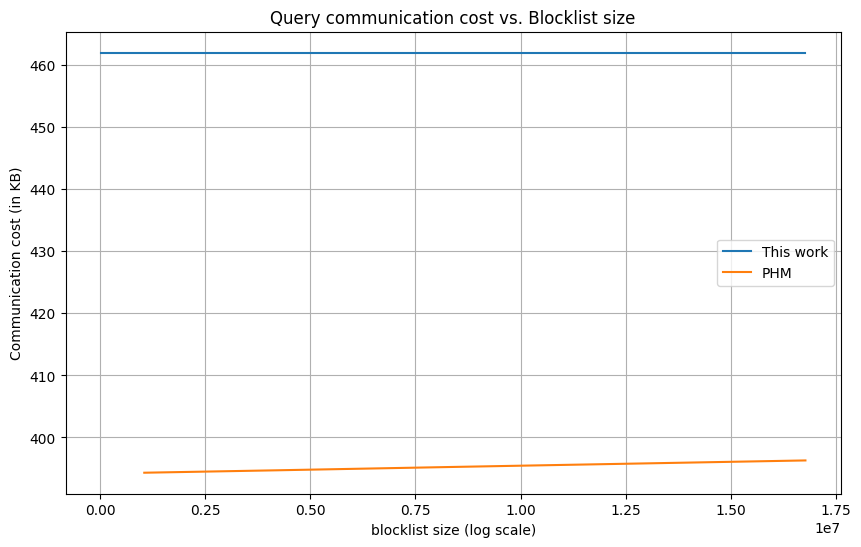

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(df_exact_pre['DB size'], df_exact_pre['comm query'], label='This work')
plt.plot(df_exact_pre['DB size'], df_exact_pre['PHM comm'], label='PHM')

# Adding labels and title
plt.xlabel('blocklist size (log scale)')
plt.ylabel('Communication cost (in KB)')
plt.title('Query communication cost vs. Blocklist size')
plt.legend()
plt.grid(True)

plt.savefig("figs/client_comm_blocklistsize.pdf", format='pdf') # Saves as PNG by default

plt.show()

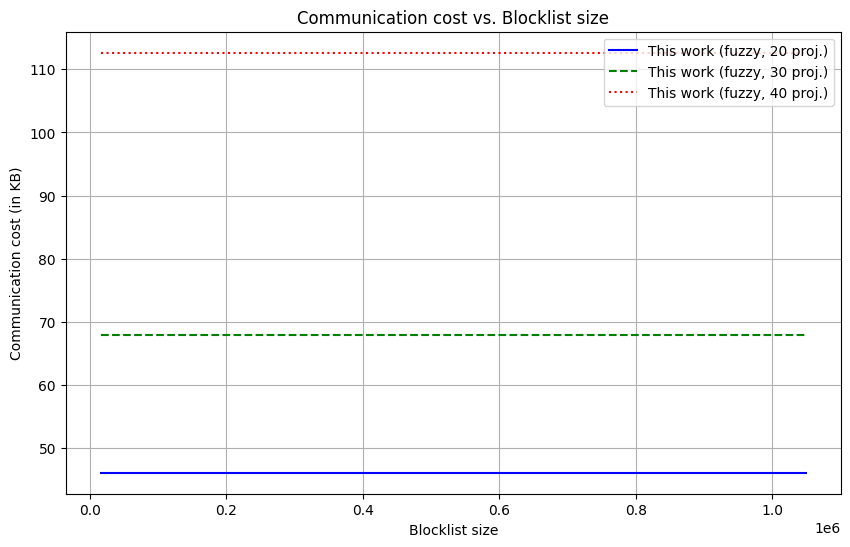

In [ ]:
plt.rcParams['axes.prop_cycle'] = plt.cycler(
    color=['b', 'g', 'r', 'c', 'm'],
    linestyle=['-', '--', ':', '-.', '-']
)


plt.figure(figsize=(10, 6))
plt.plot(df_approx_20['DB size'], df_approx_20['Comm'], label='This work (fuzzy, 20 proj.)')
plt.plot(df_approx_30['DB size'], df_approx_30['Comm'], label='This work (fuzzy, 30 proj.)')
plt.plot(df_approx_40['DB size'], df_approx_40['Comm'], label='This work (fuzzy, 40 proj.)')
#plt.plot(df_exact_pre['DB size'], df_exact_pre['PHM comm'], label='PEMC comm')


# Adding labels and title
plt.xlabel('Blocklist size (log scale)')
plt.ylabel('Communication cost (in KB)')
plt.title('Communication cost vs. Blocklist size')
plt.legend(loc='upper right')
plt.grid(True)

plt.savefig("figs/client_comm_blocklistsize.pdf", format='pdf') # Saves as PNG by default

plt.show()

In [ ]:

'''
fig, ax = plt.subplots()


df_10 = pd.DataFrame({'server DHF detection': df_approx_10['server DHF time'], 'DHF computation': df_approx_10['client DHF time'], 'Encrypt/decrypt': df_approx_10['Query time'], 'index':df_approx_10['DB size']})
df_10 = df_10.set_index('index')
df_10.plot(kind="bar", stacked=True, width=0.1, ax=ax, position=0)


df_15 = pd.DataFrame({'server DHF detection': df_approx_15['server DHF time'], 'DHF computation': df_approx_15['client DHF time'], 'Encrypt/decrypt': df_approx_15['Query time'], 'index':df_approx_15['DB size']})
df_15 = df_15.set_index('index')
df_15.plot(kind="bar", stacked=True, width=0.1, ax=ax, position=1, hatch='//')


df_20 = pd.DataFrame({'server DHF detection': df_approx_20['server DHF time'], 'DHF computation': df_approx_20['client DHF time'], 'Encrypt/decrypt': df_approx_20['Query time'], 'index':df_approx_20['DB size']})
df_20 = df_20.set_index('index')
df_20.plot(kind="bar", stacked=True, width=0.1, ax=ax, position=2, hatch='*')


df_25 = pd.DataFrame({'server DHF detection': df_approx_25['server DHF time'], 'DHF computation': df_approx_25['client DHF time'], 'Encrypt/decrypt': df_approx_25['Query time'], 'index':df_approx_25['DB size']})
df_25 = df_25.set_index('index')
df_25.plot(kind="bar", stacked=True, width=0.1, ax=ax, position=3, hatch='#')

df_30 = pd.DataFrame({'server DHF detection': df_approx_30['server DHF time'], 'DHF computation': df_approx_30['client DHF time'], 'Encrypt/decrypt': df_approx_30['Query time'], 'index':df_approx_30['DB size']})
df_30 = df_30.set_index('index')
df_30.plot(kind="bar", stacked=True, width=0.1, ax=ax, position=4, hatch='#')

ax.set_xlim(right=len(df_approx_10['DB size'])-0.5)



#ax = df.plot(kind='bar', stacked=True)
#fig = plt.figure(figsize=(10, 10))

#proj_10_list = [plt.bar(df_approx_10['DB size'], df_approx_10['server DHF time'], align='edge', width= 0.2),plt.bar(df_approx_10['DB size'], df_approx_10['client DHF time'], align='edge', width= 0.2)]
'''


plt.figure(figsize=(10, 6))
plt.plot(df_approx_20['DB size'], df_approx_20['total query time'], label='time (20 Proj., FPR < 0.04, FNR < 0.23')
plt.plot(df_approx_30['DB size'], df_approx_30['total query time'], label='time (30 Proj., FPR < 0.08, FNR < 0.07 )')
plt.plot(df_approx_40['DB size'], df_approx_40['total query time'], label='time (40 Proj., FPR < 0.02, FNR < 0.08)')
#plt.plot(df_approx_50['DB size log scale'], df_approx_50['total query time'], label='time (50 Proj., FPR < 0.009, FNR < 0.08)')


# Adding labels and title
plt.xlabel('Blocklist size (log scale)')
plt.ylabel('Upload time (in seconds)')
plt.title('Compute time vs. Blocklist size (with preprocessing)')
plt.ylim(0, 2)
plt.legend()
plt.grid(True)

plt.savefig("figs/server_sigtime_blocklistsize_pre_approx.pdf", format="pdf") # Saves as PNG by default

plt.show()

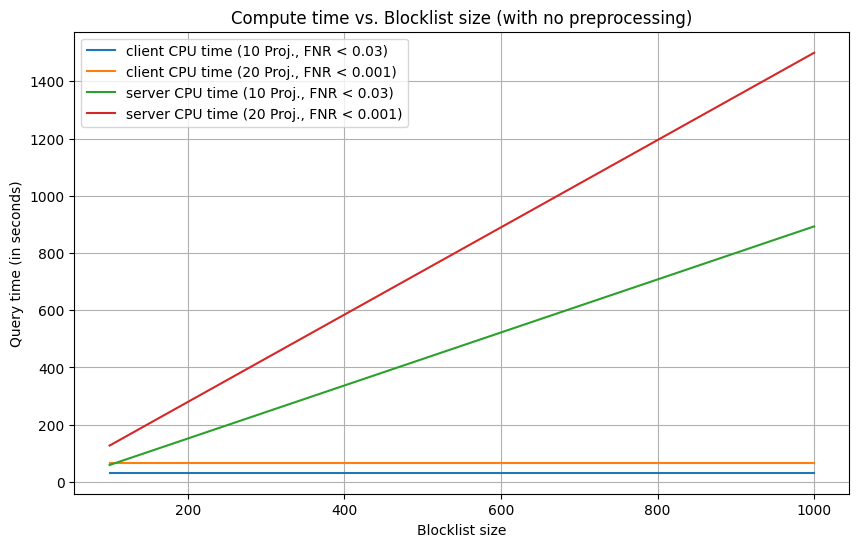

In [5]:


plt.figure(figsize=(10, 6))
plt.plot(df_approx_no_pre_10['DB size'], df_approx_no_pre_10['Client compute time'], label='client CPU time (10 Proj., FNR < 0.03)')
plt.plot(df_approx_no_pre_20['DB size'], df_approx_no_pre_20['Client compute time'], label='client CPU time (20 Proj., FNR < 0.001)')
plt.plot(df_approx_no_pre_10['DB size'], df_approx_no_pre_10['Server compute time'], label='server CPU time (10 Proj., FNR < 0.03)')
plt.plot(df_approx_no_pre_20['DB size'], df_approx_no_pre_20['Server compute time'], label='server CPU time (20 Proj., FNR < 0.001)')


# Adding labels and title
plt.xlabel('Blocklist size')
plt.ylabel('Query time (in seconds)')
plt.title('Compute time vs. Blocklist size (with no preprocessing)')
plt.legend()
plt.grid(True)

plt.savefig("figs/server_sigtime_blocklistsize_nopre_approx.pdf", format="pdf") # Saves as PNG by default

plt.show()

In [ ]:
plt.figure(figsize=(10, 6))